# Quantity Prediction — Multi-class Classification

This notebook predicts the **quantity ordered** when a customer makes a purchase, framed as a 5-class classification problem.

## Approach
- Filter the dataset to rows where `order == 1` (only customers who actually bought).
- Compute the actual quantity ordered as `revenue / price`.
- Bin the quantity into 5 ordinal classes: `1`, `2`, `3`, `4-5`, `6+`.
- Train a classifier and evaluate on a held-out test set.

## Why classification (not regression)?
The quantity target is a discrete count, heavily right-skewed: roughly 80% of orders are exactly 1 unit. A regression model would be dominated by the mean and punished by the long tail. Treating it as classification on coarse bins keeps the rare-but-relevant "customer buys many units" signal usable while making the metrics easier to interpret.

## Why these specific bins?
Quantities of 6 or more occur in less than 1% of orders combined. Splitting them into finer bins (7-8, 9-10, 10+) leaves only dozens of training examples per class, which a model cannot reliably learn from. Collapsing to `6+` keeps every class with hundreds of examples while still distinguishing "single unit", "small multi-pack", and "bulk buyer".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

FULL_DATA_PATH = "../../../data/processed/processed_joined_dataset.csv"
SAMPLE_DATA_PATH = "../../../data/processed/sample.csv"

USE_FULL_DATA = False        # keep False during development
RANDOM_STATE = 42
TEST_SIZE = 0.2

CLASS_ORDER = ["1", "2", "3", "4-5", "6+"]

data_path = FULL_DATA_PATH if USE_FULL_DATA else SAMPLE_DATA_PATH
print("Using:", data_path)

Using: ../../../data/processed/sample.csv


## Load the processed dataset

The `processed_joined_dataset.csv` already merges `items.csv` and `train.csv` on `pid`, plus it includes feature engineering done by the team: competitor price flags, campaign one-hots, price ratios, the `is_post_shift_day` regime indicator, and the previous-day price-difference feature.

For development we work on the 200k stratified sample (`sample.csv`). Once the model pipeline is solid we can switch to the full ~2.75M dataset by flipping `USE_FULL_DATA`.

In [2]:
df = pd.read_csv(data_path, sep="|")
print("Shape:", df.shape)
display(df.head())

Shape: (200000, 29)


,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day
0,978899,39,9624,0,1,17.19,1,0,0,19.89,...,21.51,1,0,0,0,2.70,1.1571,15.71,1,0.0
1,1267035,47,3969,1,1,18.13,1,0,0,20.85,...,26.07,1,0,0,0,2.72,1.1500,15.00,1,0.0
2,297914,14,16633,0,1,15.06,0,0,1,16.45,...,23.98,1,0,1,0,1.39,1.0923,9.23,0,0.0
3,2554963,87,20147,0,1,4.36,1,0,0,5.17,...,5.45,1,0,0,0,0.81,1.1858,18.58,1,0.0
4,2739211,92,14326,0,1,NaN,0,0,1,6.22,...,6.55,0,0,0,0,NaN,NaN,NaN,1,0.0


## Build the target

Two steps:

1. **Filter to orders only** — we only want to predict quantity for customers who actually purchased. Rows with `order == 0` are not relevant for this question (they're handled by the classification model which predicts if item is bought or not).
2. **Compute quantity** — the dataset doesn't store quantity directly, but `revenue = price × quantity`, so we recover it as `revenue / price`. We round to the nearest integer because quantities are discrete units.

In [5]:
df_orders = df[df["order"] == 1].copy()
df_orders["quantity"] = (df_orders["revenue"] / df_orders["price"]).round().astype(int)

print("Orders shape:", df_orders.shape)
print(f"Quantity range: {df_orders['quantity'].min()} to {df_orders['quantity'].max()}")
display(df_orders["quantity"].describe())

Orders shape: (51171, 30)
Quantity range: 1 to 200


count    51171.000000
mean         1.370229
std          1.525825
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        200.000000
Name: quantity, dtype: float64

## Bin the quantity into 5 classes

The raw quantity ranges from 1 up to 200, but is overwhelmingly concentrated at small values. We collapse it into ordinal bins:

| Class | Meaning |
|-------|---------|
| `1`   | Single unit |
| `2`   | Two units |
| `3`   | Three units |
| `4-5` | Small multi-pack |
| `6+`  | Bulk purchase |

In [6]:
def bin_quantity(q):
    if q <= 3:
        return str(q)
    if q <= 5:
        return "4-5"
    return "6+"

df_orders["quantity_class"] = df_orders["quantity"].apply(bin_quantity)

class_counts = df_orders["quantity_class"].value_counts().reindex(CLASS_ORDER)
class_pct = (class_counts / len(df_orders) * 100).round(2)
display(pd.DataFrame({"count": class_counts, "percent": class_pct}))

,count,percent
quantity_class,,
1,40856,79.84
2,6855,13.40
3,1711,3.34
4-5,1264,2.47
6+,485,0.95


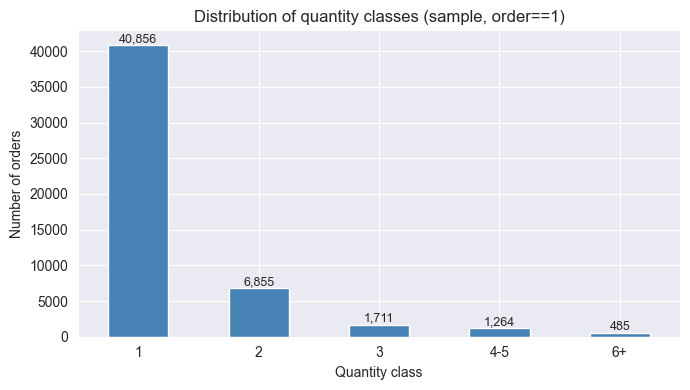

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribution of quantity classes (sample, order==1)")
ax.set_xlabel("Quantity class")
ax.set_ylabel("Number of orders")
ax.set_xticklabels(CLASS_ORDER, rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Train/test split

We split the orders into 80% training and 20% test before doing any feature engineering or model fitting. The split is **stratified** on `quantity_class` so that each class keeps the same proportion in both sets — this matters because the rare classes (`4-5`, `6+`) are otherwise easy to lose entirely from the test set by chance.

Random state is fixed so the split is reproducible across reruns.

In [8]:
train_df, test_df = train_test_split(
    df_orders,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_orders["quantity_class"],
)

print(f"Train: {len(train_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

# Confirm the stratification preserved class balance
display(pd.DataFrame({
    "train_pct": (train_df["quantity_class"].value_counts(normalize=True) * 100).round(2),
    "test_pct":  (test_df["quantity_class"].value_counts(normalize=True) * 100).round(2),
}).reindex(CLASS_ORDER))

Train: 40,936 rows
Test:  10,235 rows


,train_pct,test_pct
quantity_class,,
1,79.84,79.84
2,13.40,13.40
3,3.34,3.34
4-5,2.47,2.47
6+,0.95,0.95


## Establish the baseline

Before training any model, we set the bar with a trivial baseline: **always predict class `1`** (the majority class). Any real model has to clearly beat this on more than just accuracy, since accuracy alone rewards predicting the dominant class.

Three metrics to track:

- **Accuracy** — fraction of correct predictions. Inflated by the dominant class, so on its own it's misleading. The naive baseline already gets ~80%.
- **Macro F1** — average F1 across all 5 classes, weighted equally. This is the metric that actually punishes ignoring the rare classes. The baseline will score very low here because it gets zero F1 on classes 2, 3, 4-5, and 6+.
- **Confusion matrix** — shows where the model's mistakes are concentrated. With ordinal classes, mistakes between adjacent classes (e.g. predicting `2` when truth is `1`) are much less bad than far-apart mistakes (e.g. predicting `6+` when truth is `1`).

In [9]:
y_test = test_df["quantity_class"].values
y_pred_baseline = np.array(["1"] * len(y_test))

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline,
                       average="macro", labels=CLASS_ORDER, zero_division=0)

print(f"Baseline accuracy: {baseline_acc:.4f}")
print(f"Baseline macro F1: {baseline_f1:.4f}")
print()
print("Confusion matrix (rows=true, cols=predicted):")
cm = confusion_matrix(y_test, y_pred_baseline, labels=CLASS_ORDER)
display(pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER))
print()
print("Classification report:")
print(classification_report(y_test, y_pred_baseline,
                            labels=CLASS_ORDER, zero_division=0))

Baseline accuracy: 0.7984
Baseline macro F1: 0.1776

Confusion matrix (rows=true, cols=predicted):


,1,2,3,4-5,6+
1,8172,0,0,0,0
2,1371,0,0,0,0
3,342,0,0,0,0
4-5,253,0,0,0,0
6+,97,0,0,0,0



Classification report:
              precision    recall  f1-score   support

           1       0.80      1.00      0.89      8172
           2       0.00      0.00      0.00      1371
           3       0.00      0.00      0.00       342
         4-5       0.00      0.00      0.00       253
          6+       0.00      0.00      0.00        97

    accuracy                           0.80     10235
   macro avg       0.16      0.20      0.18     10235
weighted avg       0.64      0.80      0.71     10235

